## **computer vision - lab 2 - task 3**
### **real-time echocardiogram video analysis**
#### **23K-0074**

#### **setup**

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)


def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"could not read '{path}' - put the sample file in the data/ folder (see README.md)")
    return img


def log_transform(img):
    # s = c * log(1 + r), with c chosen so the brightest input maps to 255
    f = img.astype(np.float64)
    c = 255.0 / np.log1p(max(f.max(), 1.0))
    return np.clip(c * np.log1p(f), 0, 255).astype(np.uint8)


def gamma_transform(img, gamma):
    # s = 255 * (r / 255) ^ gamma  (gamma < 1 brightens, gamma > 1 darkens)
    f = img.astype(np.float64) / 255.0
    return np.clip(255.0 * np.power(f, gamma), 0, 255).astype(np.uint8)


def gray_world_balance(bgr):
    # scale each channel so its mean equals the overall mean -> removes a global colour cast
    f = bgr.astype(np.float64)
    means = f.reshape(-1, 3).mean(axis=0)
    gain = means.mean() / np.maximum(means, 1e-6)
    return np.clip(f * gain, 0, 255).astype(np.uint8)


def show(images, titles, figsize=(15, 5), save=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, im, t in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join("output", save), dpi=120, bbox_inches="tight")
    plt.show()

VIDEO_PATH = "data/echo.mp4"

#### **the per-frame enhancement pipeline**
1. grayscale → **histogram equalization** (fixes murky contrast)
2. **COLORMAP_JET** (intensity → colour, highlights blood-flow / chamber intensities)
3. **gray-world colour balance**
4. **log transform** (reveals the darkest regions - the heart chambers)
5. **power-law, γ > 1** (suppresses the bright white backscatter noise)

In [6]:
GAMMA = 1.5


def enhance(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    eq = cv2.equalizeHist(gray)
    jet = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
    balanced = gray_world_balance(jet)
    logged = log_transform(balanced)
    return gamma_transform(logged, GAMMA)


def label(img, text):
    out = img.copy()
    cv2.putText(out, text, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
    return out

#### **preview one frame**

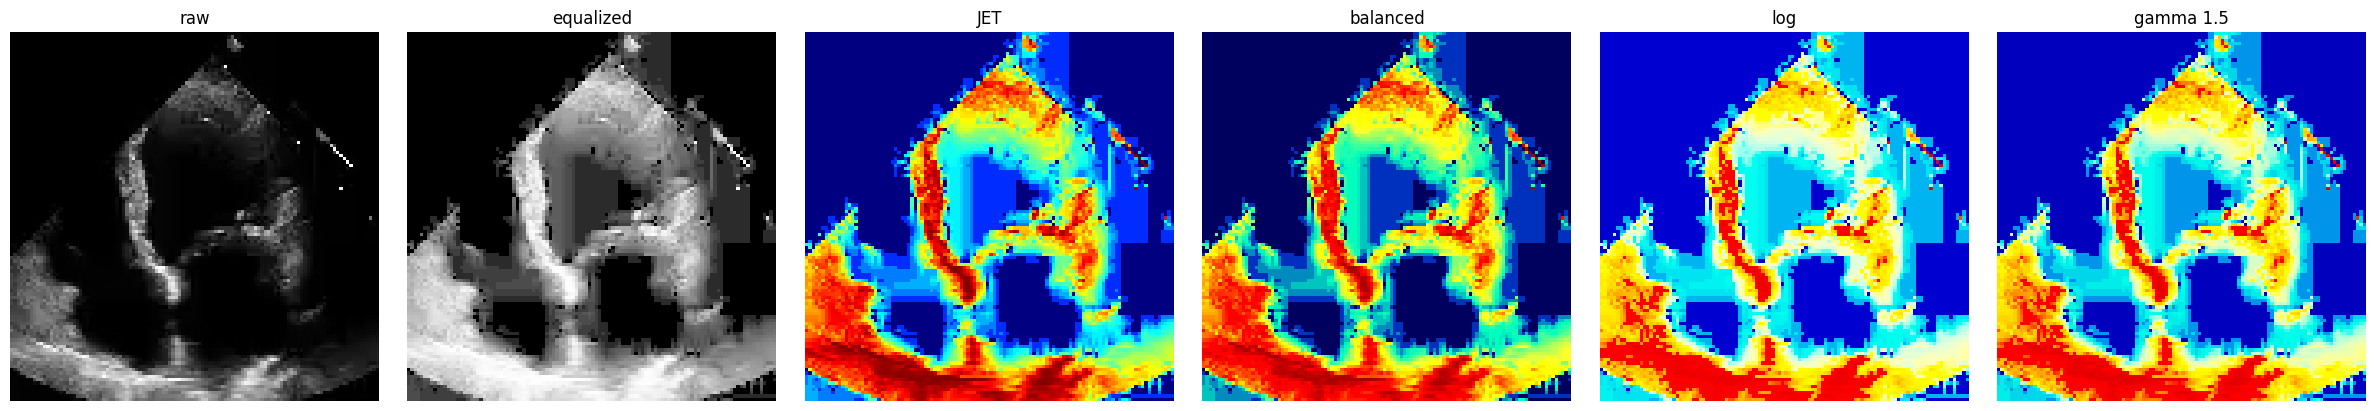

In [7]:
cap = cv2.VideoCapture(VIDEO_PATH)
ok, frame = cap.read()
cap.release()
if not ok:
    raise FileNotFoundError(f"could not read '{VIDEO_PATH}' - put the echo clip in the data/ folder (see README.md)")

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
eq = cv2.equalizeHist(gray)
jet = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
bal = gray_world_balance(jet)
lg = log_transform(bal)
gm = gamma_transform(lg, GAMMA)
show([gray, eq, jet, bal, lg, gm], ["raw", "equalized", "JET", "balanced", "log", f"gamma {GAMMA}"], figsize=(24, 4), save="01_pipeline_stages.png")

**observation (stage by stage):**
- **raw:** a dark, grainy apical four-chamber view of the heart. The chambers are black and the heart walls are faint gray streaks.
- **equalized:** the walls, valves and the edges of the ultrasound fan become clearly visible. The black chambers now stand out from the tissue. The speckle grain is amplified too.
- **JET:** the heart walls and valves turn **red / yellow** and the blood-filled chambers stay **dark blue**, so the outline of each chamber is easy to follow. (this is a standard grayscale echo, so the colour shows brightness, not true Doppler blood-flow speed.)
- **gray-world balance:** almost no visible change, because this frame had no strong colour cast.
- **log:** lifts the dark chambers to a lighter blue so their inside is visible, but pushes the walls and speckle into saturated red / yellow.
- **gamma 1.5:** compresses those over-bright areas back down, reducing the glare from the bright backscatter noise while keeping the chamber detail that log revealed.

#### **real-time processing loop + monitoring array**
reads every frame with `cv2.VideoCapture`, runs the pipeline, stacks **raw | enhanced** with `np.hstack` and shows it live with `cv2.imshow`. the clip loops until **q** is pressed. a few side-by-side frames and the full side-by-side video are also saved to `output/`.

In [8]:
import time

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"could not open '{VIDEO_PATH}'")

fps = cap.get(cv2.CAP_PROP_FPS) or 30
delay = max(1, int(1000 / fps))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"{w}x{h} @ {fps:.1f} fps, {total} frames")

SCALE = 3  # echonet clips are tiny (112x112), so upscale for display
writer = cv2.VideoWriter("output/side_by_side.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (2 * w * SCALE, h * SCALE))
snapshots = {0, total // 4, total // 2, 3 * total // 4}
frame_idx, first_pass = 0, True
proc_times = []  # processing time per frame (first pass only)

while True:
    ok, frame = cap.read()
    if not ok:
        # end of clip -> loop back to the start
        first_pass = False
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        frame_idx = 0
        continue

    t0 = time.perf_counter()
    enhanced = enhance(frame)
    monitor = np.hstack([frame, enhanced])
    monitor = cv2.resize(monitor, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)
    monitor = label(monitor, "raw")
    cv2.putText(monitor, "enhanced", (w * SCALE + 8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
    elapsed_ms = (time.perf_counter() - t0) * 1000

    if first_pass:
        proc_times.append(elapsed_ms)
        writer.write(monitor)
        if frame_idx in snapshots:
            cv2.imwrite(f"output/frame_{frame_idx:03d}.png", monitor)

    cv2.imshow("echocardiogram - raw | enhanced  (q to quit)", monitor)
    frame_idx += 1
    if cv2.waitKey(delay) & 0xFF == ord("q"):
        break

cap.release()
writer.release()
cv2.destroyAllWindows()
print(f"processing time: {np.mean(proc_times):.2f} ms/frame on average (max {np.max(proc_times):.2f} ms) "
      f"- budget at {fps:.0f} fps is {1000 / fps:.1f} ms/frame")
print("done - side-by-side frames and video saved to output/")

112x112 @ 50.0 fps, 335 frames
processing time: 2.74 ms/frame on average (max 4.48 ms) - budget at 50 fps is 20.0 ms/frame
done - side-by-side frames and video saved to output/


**observation (live feed):**
- **the clip:** 112×112 pixels, 50 fps, 335 frames. It's upscaled 3× for display and shown as **raw | enhanced** side by side.
- **performance:** the loop prints the average processing time per frame (enhancement plus stacking, upscaling and labelling). In testing this was about **3 ms**, far below the **20 ms** each frame gets at 50 fps, so the pipeline comfortably runs in real time. (the exact number depends on the machine; check the printed value above.)
- **in the enhanced feed:** this is an apical four-chamber view. In the enhanced feed the outline of every chamber is traced in colour, so you can clearly follow the chambers changing shape as the heart beats. In the raw feed these outlines are faint and easy to lose.
- **snapshots:** `output/frame_000.png`, `frame_083.png`, `frame_167.png` and `frame_251.png`, plus the full `output/side_by_side.mp4`.